In [1]:
import pandas as pd

df = pd.read_csv("sales_cleaned.csv")
print(df.shape)       
print(df.columns.tolist())

(482, 10)
['Order_ID', 'Order_Date', 'Customer', 'Region', 'Product', 'Sales', 'Cost', 'Profit', 'Year', 'Month']


In [2]:
model_df = df[['Region', 'Product', 'Month', 'Year', 'Sales', 'Cost', 'Profit']].copy()
print(model_df.isnull().sum())

Region     0
Product    0
Month      0
Year       0
Sales      0
Cost       0
Profit     0
dtype: int64


In [3]:
model_encoded = pd.get_dummies(model_df, columns=['Region', 'Product'])
print(model_encoded.shape)
print(model_encoded.columns.tolist())

(482, 14)
['Month', 'Year', 'Sales', 'Cost', 'Profit', 'Region_East', 'Region_North', 'Region_South', 'Region_West', 'Product_Laptop', 'Product_Mobile', 'Product_Monitor', 'Product_Printer', 'Product_Tablet']


In [11]:
# Cell 4 - replace with this
X = model_encoded.drop(['Profit', 'Cost'], axis=1)  # remove Cost too
y = model_encoded['Profit']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (482, 12)
y shape: (482,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape[0], "rows")
print("Test:", X_test.shape[0], "rows")

Train: 385 rows
Test: 97 rows


In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
print("✅ Model trained!")

✅ Model trained!


In [14]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score : {r2:.2f}")
print(f"MAE      : ₹{mae:,.0f}")

R² Score : 0.48
MAE      : ₹3,357


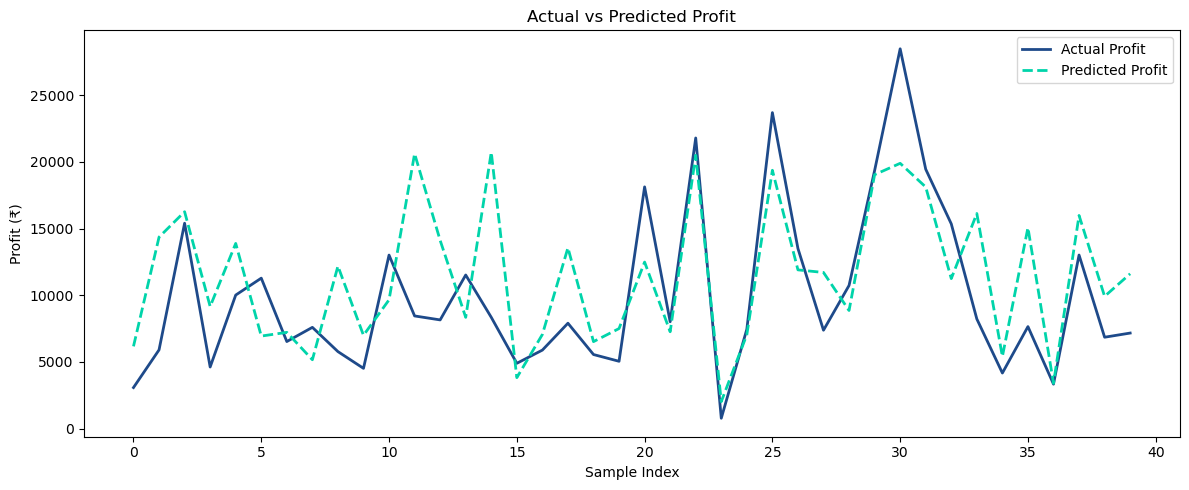

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:40], label='Actual Profit', color='#1e4a8a', linewidth=2)
plt.plot(y_pred[:40], label='Predicted Profit', color='#00d4aa', linewidth=2, linestyle='--')
plt.title('Actual vs Predicted Profit')
plt.xlabel('Sample Index')
plt.ylabel('Profit (₹)')
plt.legend()
plt.tight_layout()
plt.savefig("profit_prediction_chart.png")
plt.show()

In [16]:
results = pd.DataFrame({
    'Actual_Profit': y_test.values,
    'Predicted_Profit': y_pred.round(0)
})
results.to_csv("profit_predictions.csv", index=False)
print("✅ Saved profit_predictions.csv")
print(results.head(10))

✅ Saved profit_predictions.csv
   Actual_Profit  Predicted_Profit
0           3081            6172.0
1           5908           14364.0
2          15405           16269.0
3           4623            9160.0
4          10018           13890.0
5          11286            6943.0
6           6533            7222.0
7           7597            5168.0
8           5778           12189.0
9           4523            6999.0


In [17]:
# Get original rows that were in test set
test_indices = X_test.index

# Pull original readable data
original_cols = df.loc[test_indices, ['Region', 'Product', 'Month', 'Year', 'Sales']].copy()
original_cols['Actual_Profit'] = y_test.values
original_cols['Predicted_Profit'] = y_pred.round(0)

original_cols.to_csv("profit_predictions_full.csv", index=False)
print("✅ Saved!")
print(original_cols.head(10))

✅ Saved!
    Region  Product  Month  Year  Sales  Actual_Profit  Predicted_Profit
416   East   Mobile      3  2023  24840           3081            6172.0
472  North  Monitor     12  2023  52826           5908           14364.0
181   East  Printer     12  2023  60576          15405           16269.0
444  North   Laptop      3  2023  35339           4623            9160.0
297  North   Tablet      6  2023  52127          10018           13890.0
148   West   Mobile      6  2023  31318          11286            6943.0
379  South  Monitor      2  2023  27865           6533            7222.0
418   West   Tablet      7  2023  23327           7597            5168.0
477  South  Monitor     10  2023  46709           5778           12189.0
227   West  Printer     11  2023  28891           4523            6999.0
